# Blur Detection Algorithm

The purpose of this will be to check how blurry an image is by checking its lows and high variange using variance of laplacian

In [ ]:
import cv2
# Apply LoG Laplacian of Gaussian
def variance_of_LoG(image):
    """Computes the variance of laplacian of an image and then returns the focus"""
    blurred = cv2.GaussianBlur(image, (5,5), 0)
    return cv2.Laplacian(blurred, cv2.CV_64F).var()

def is_blurry(image, threshold = 72.27):
    """Checks if the image is blurry or not by checking if the image variance of laplacian is below or 
    above the threshold"""
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    laplacian_var = variance_of_LoG(gray_image)

    return laplacian_var < threshold, laplacian_var

In [ ]:
import cv2
# Apply LoG Laplacian of Gaussian
def variance_of_laplacian(image):
    """Computes the variance of laplacian of an image and then returns the focus"""
    return cv2.Laplacian(image, cv2.CV_64F).var()

def is_blurry(image, threshold = 37.771):
    """Checks if the image is blurry or not by checking if the image variance of laplacian is below or 
    above the threshold"""
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    laplacian_var = variance_of_laplacian(gray_image)

    return laplacian_var < threshold, laplacian_var


Processed : 180 images
Skipped   : 0 unreadable files

═══════════════════════════════════════════════════════
GROUP                         N    MEAN   MEDIAN     STD     MIN     MAX
═══════════════════════════════════════════════════════
blur                         15   38.80    28.69   32.10    8.06  134.03
blur+glare                   23   20.86    13.84   15.49    7.06   62.61
blur+glare+rotate            66   21.85    18.70   12.53    5.62   55.69
blur+rotate                  22   32.06    26.69   21.82    7.65   74.90
glare                        16   95.63    86.17   51.71   15.32  206.91
glare+rotate                 20   65.28    65.87   32.12   15.08  160.54
rotate                       18   88.95    94.68   52.03   19.16  196.50
═══════════════════════════════════════════════════════

Optimal blur threshold : 72.27  (F1 = 0.175)
Old mean threshold     : 37.10
Images below threshold : 145 (classified as blur-dominant)

Plot saved → blur_analysis.png


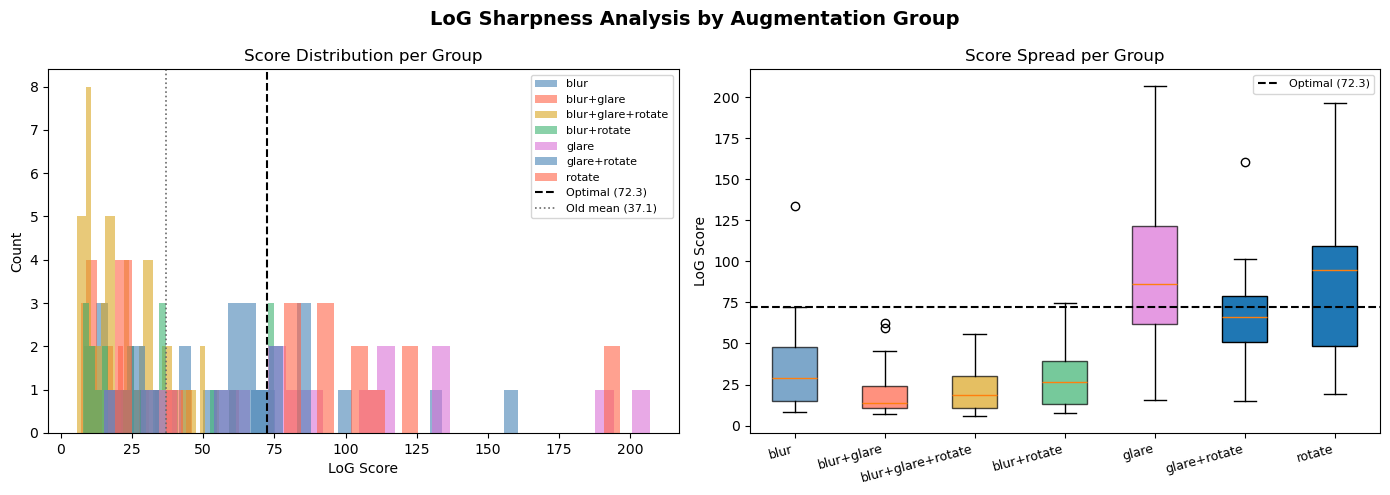

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ─────────────────────────────────────────────
# CONFIG — change this to your dataset folder
# ─────────────────────────────────────────────
IMAGE_DIR = "Datasets/Augmented/Front"
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")

# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────
def get_group_label(filename):
    name = os.path.basename(filename).lower()
    parts = []
    if "blur"   in name: parts.append("blur")
    if "glare"  in name: parts.append("glare")
    if "rotate" in name: parts.append("rotate")
    return "+".join(parts) if parts else "clean"


def log_score(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    blurred = cv2.GaussianBlur(img, (5, 5), sigmaX=1.0)
    return cv2.Laplacian(blurred, cv2.CV_64F).var()


def glare_ratio(image_path):
    """Fraction of pixels blown out above brightness 240."""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return np.sum(img > 240) / img.size


# ─────────────────────────────────────────────
# COLLECT SCORES
# ─────────────────────────────────────────────
all_image_paths = [
    os.path.join(root, f)
    for root, _, files in os.walk(IMAGE_DIR)
    for f in files
    if f.lower().endswith(IMAGE_EXTS)
]

if not all_image_paths:
    raise FileNotFoundError(f"No images found in: {IMAGE_DIR}")

group_scores  = defaultdict(list)
group_glare   = defaultdict(list)
skipped       = []

for path in all_image_paths:
    score = log_score(path)
    glare = glare_ratio(path)
    if score is None:
        skipped.append(path)
        continue
    label = get_group_label(path)
    group_scores[label].append(score)
    group_glare[label].append(glare)

print(f"\nProcessed : {len(all_image_paths) - len(skipped)} images")
print(f"Skipped   : {len(skipped)} unreadable files")

# ─────────────────────────────────────────────
# PER-GROUP STATS
# ─────────────────────────────────────────────
print("\n" + "═" * 55)
print(f"{'GROUP':<25} {'N':>5} {'MEAN':>7} {'MEDIAN':>8} {'STD':>7} {'MIN':>7} {'MAX':>7}")
print("═" * 55)

for group in sorted(group_scores):
    arr = np.array(group_scores[group])
    g   = np.array(group_glare[group])
    print(
        f"{group:<25} {len(arr):>5} {arr.mean():>7.2f} "
        f"{np.median(arr):>8.2f} {arr.std():>7.2f} "
        f"{arr.min():>7.2f} {arr.max():>7.2f}"
    )
    # Warn if glare is inflating scores
    high_glare = np.sum(g > 0.05)
    if high_glare > 0:
        print(f"  ⚠️  {high_glare}/{len(arr)} images have >5% glare pixels (scores may be inflated)")

print("═" * 55)

# ─────────────────────────────────────────────
# OPTIMAL THRESHOLD (blur-only vs everything else)
# ─────────────────────────────────────────────
from sklearn.metrics import f1_score

labels_bin, scores_all = [], []
for group, scores in group_scores.items():
    for s in scores:
        # blur-only = 1 (most degraded), rest = 0
        labels_bin.append(1 if group == "blur" else 0)
        scores_all.append(s)

thresholds = np.linspace(min(scores_all), max(scores_all), 300)
best_thresh, best_f1 = 0, 0
for t in thresholds:
    preds = [1 if s < t else 0 for s in scores_all]
    f1 = f1_score(labels_bin, preds, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

print(f"\nOptimal blur threshold : {best_thresh:.2f}  (F1 = {best_f1:.3f})")
print(f"Old mean threshold     : 37.10")
print(f"Images below threshold : {sum(1 for s in scores_all if s < best_thresh)} (classified as blur-dominant)")

# ─────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────
COLORS = ["steelblue", "tomato", "goldenrod", "mediumseagreen", "orchid"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LoG Sharpness Analysis by Augmentation Group", fontsize=14, fontweight="bold")

# --- Histogram ---
ax = axes[0]
for i, (group, scores) in enumerate(sorted(group_scores.items())):
    ax.hist(scores, bins=30, alpha=0.6, label=group, color=COLORS[i % len(COLORS)])
ax.axvline(best_thresh, color="black",     linestyle="--", linewidth=1.5, label=f"Optimal ({best_thresh:.1f})")
ax.axvline(37.1,        color="dimgray",   linestyle=":",  linewidth=1.2, label="Old mean (37.1)")
ax.set_xlabel("LoG Score")
ax.set_ylabel("Count")
ax.set_title("Score Distribution per Group")
ax.legend(fontsize=8)

# --- Box plot ---
ax2 = axes[1]
sorted_groups = sorted(group_scores.keys())
data = [group_scores[g] for g in sorted_groups]
bp = ax2.boxplot(data, patch_artist=True, notch=False)
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.axhline(best_thresh, color="black", linestyle="--", linewidth=1.5, label=f"Optimal ({best_thresh:.1f})")
ax2.set_xticklabels(sorted_groups, rotation=15, ha="right", fontsize=9)
ax2.set_ylabel("LoG Score")
ax2.set_title("Score Spread per Group")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("blur_analysis.png", dpi=150, bbox_inches="tight")
print("\nPlot saved → blur_analysis.png")
plt.show()

# Edge Detection Algorithm 